# Dynamics for a Non integrable Hamiltonian

#### Imports

In [3]:
from qutip_class import SpinOperator,SpinHamiltonian,SteadyStateSolver
import numpy as np
import qutip
from tqdm import tqdm
from typing import Dict,List,Tuple,Union
import matplotlib.pyplot as plt
from qutip.solver import Options


#### Hyperparameters

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 



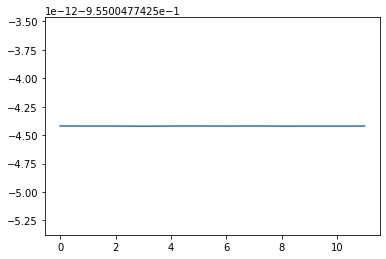

In [4]:
size:int=12
pbc:bool=False
j:float=1.
coupling_noise:float=1.
dir_coupling:Tuple[str]=('x','x')
dir_field:str='z'


t:np.ndarray = np.linspace(0, 15, 10000)
hi:float=1.
hf:float=2.
gamma:float=2.

#observables
obs:List[qutip.Qobj]=[]
#zz=SpinOperator(index=[('z',int(size/2),'z',int(size/2)+1)],coupling=[1.],size=size)
#obs.append(zz.qutip_op)

    

class RealQuench:
    def __init__(
        self,
        hi: Union[float, np.ndarray],
        hf: Union[float, np.ndarray],
        gamma: float,
    ) -> None:

        self.hi: Union[np.ndarray, float] = hi
        self.hf: Union[np.ndarray, float] = hf
        self.gamma: float = gamma

    def field(self, t: float,args) -> Union[np.ndarray, float]:

        return (
            np.exp(-1 * (t * self.gamma)) * self.hi
            + (1 - np.exp(-1 * (t * self.gamma))) * self.hf
        )
        
ham0=SpinHamiltonian(direction_couplings=[('z','z')],field_directions=['z'],field_values=[1.],pbc=True,coupling_values=[1.],size=size)
h1=SpinHamiltonian(field_directions=['x'],field_values=[0.5],size=size,pbc=True)

field_coeff=RealQuench(hi=hi,hf=hf,gamma=gamma)

ham=[ham0.qutip_op,[h1.qutip_op,field_coeff.field]]

_,psi0=np.linalg.eigh(ham0.qutip_op+5.*h1.qutip_op)



psi0=psi0[:,0]


psi=qutip.Qobj(psi0,shape=psi0.shape,dims=([[2 for i in range(size)],[1]]))

for r in np.isnan(psi0):
    if r==True:
        print(r) 

x_gs=[]

for i in range(size):
    x=SpinOperator(index=[('x',i)],coupling=[1.],size=size,verbose=1)
    obs.append(x.qutip_op)
    x_gs.append(x.expect_value(psi))
    
plt.plot(x_gs)
    


#### Evolution

In [5]:
#options = Options(num_cpus=4, atol=1e-20)

output=qutip.mcsolve(ham,psi,t,e_ops=obs)

No c_ops, using sesolve
10.0%. Run time:   8.32s. Est. time left: 00:00:01:14
20.0%. Run time:  16.49s. Est. time left: 00:00:01:05
30.0%. Run time:  25.37s. Est. time left: 00:00:00:59
40.0%. Run time:  33.53s. Est. time left: 00:00:00:50
50.0%. Run time:  43.39s. Est. time left: 00:00:00:43
60.0%. Run time:  52.17s. Est. time left: 00:00:00:34
70.0%. Run time:  60.92s. Est. time left: 00:00:00:26
80.0%. Run time:  70.12s. Est. time left: 00:00:00:17
90.0%. Run time:  79.44s. Est. time left: 00:00:00:08
Total run time:  88.68s


12


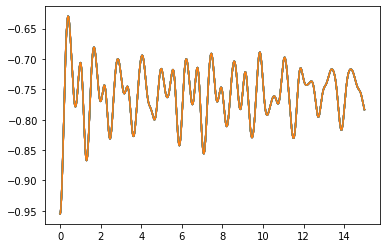

In [6]:
print(len(output.expect))
for i in range(size):
    plt.plot(t,output.expect[i],label=r'$x_$'+f'{i}')
plt.show()